In [13]:
print('hello world')

hello world


In [14]:
#!pip install opencv-python

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [4]:
base_path = "D:/AI COURSE/Daily_practice/PROJECTS/Retinopathy/aptos2019-blindness-detection/"
train_images_path = os.path.join(base_path, "train_images")

train_df = pd.read_csv(os.path.join(base_path, "train.csv"))

# Add full image path
train_df['image_path'] = train_df['id_code'].apply(
    lambda x: os.path.join(train_images_path, x + ".png")
)

# Binary label: 0 = No DR, 1 = Has DR
train_df['binary_label'] = train_df['diagnosis'].apply(lambda x: 0 if x == 0 else 1)

print("Dataset loaded.")
print("Total samples:", len(train_df))
print(train_df[['id_code', 'diagnosis', 'binary_label']].head())

Dataset loaded.
Total samples: 3662
        id_code  diagnosis  binary_label
0  000c1434d8d7          2             1
1  001639a390f0          4             1
2  0024cdab0c1e          1             1
3  002c21358ce6          0             0
4  005b95c28852          0             0


## EDA - class distribution

Class distribution:
binary_label
1    1857
0    1805
Name: count, dtype: int64

No DR: 1805
Has DR: 1857


C:\Users\SAMI\AppData\Local\Temp\ipykernel_9096\1382028262.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='binary_label', data=train_df, palette='Set2')


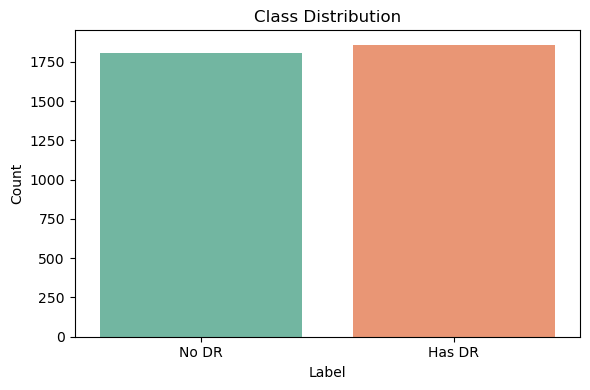

In [17]:
print("Class distribution:")
print(train_df['binary_label'].value_counts())
print(f"\nNo DR: {(train_df['binary_label'] == 0).sum()}")
print(f"Has DR: {(train_df['binary_label'] == 1).sum()}")

plt.figure(figsize=(6, 4))
sns.countplot(x='binary_label', data=train_df, palette='Set2')
plt.xticks([0, 1], ['No DR', 'Has DR'])
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## EDA - sample images

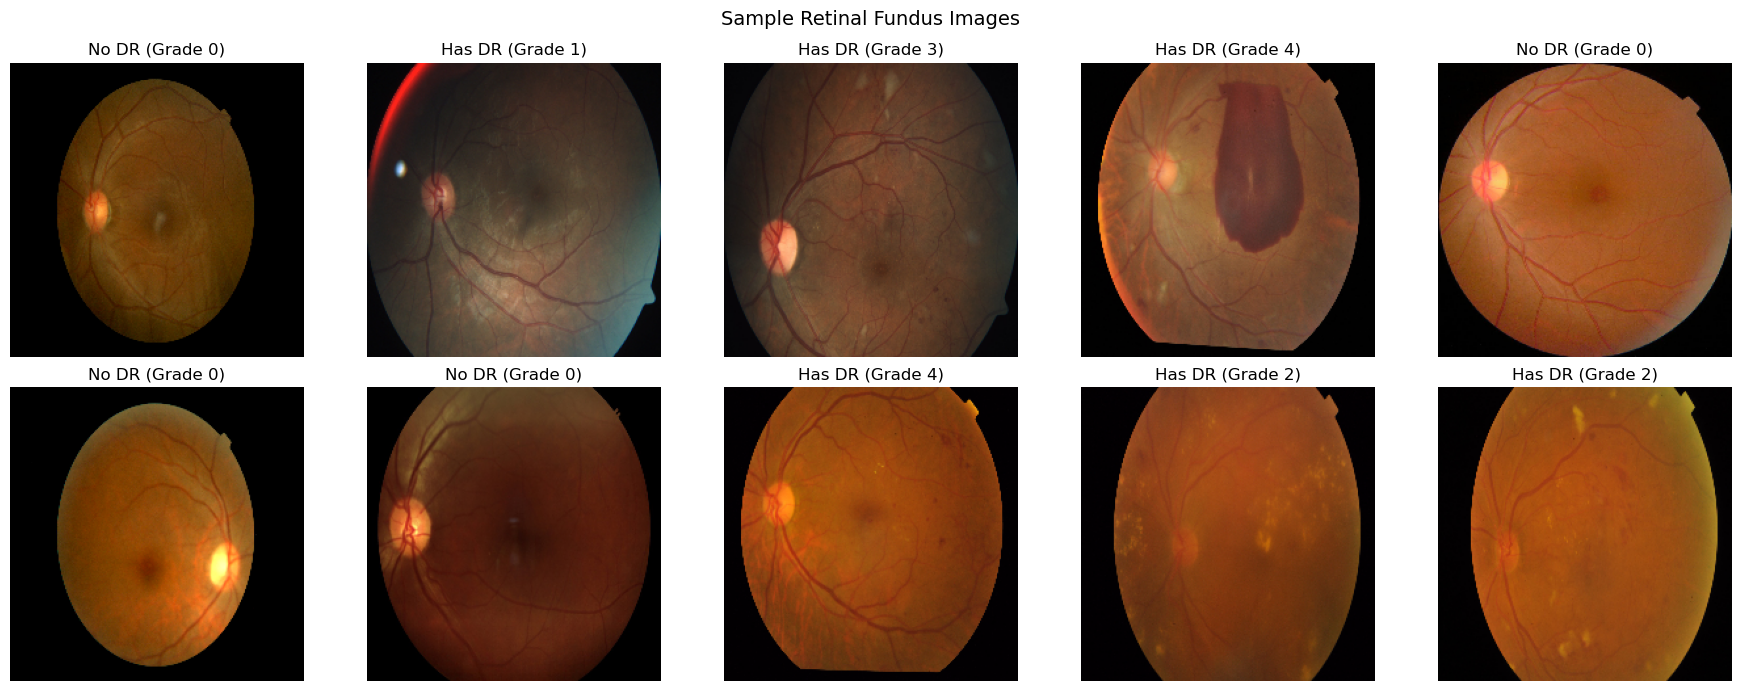

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

samples = train_df.sample(10, random_state=42).reset_index(drop=True)

for i, row in samples.iterrows():
    img = cv2.imread(row['image_path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    axes[i].imshow(img)
    label = "No DR" if row['binary_label'] == 0 else "Has DR"
    axes[i].set_title(f"{label} (Grade {row['diagnosis']})")
    axes[i].axis('off')

plt.suptitle("Sample Retinal Fundus Images", fontsize=14)
plt.tight_layout()
plt.show()

## training & validation 

In [8]:
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['binary_label']
)

train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")

Training samples: 2929
Validation samples: 733


## data generators

In [9]:
IMG_SIZE = 224
BATCH_SIZE = 16

def load_and_preprocess(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    return img

def data_generator(dataframe, batch_size, augment=False, class_weights=None):
    while True:
        dataframe = dataframe.sample(frac=1).reset_index(drop=True)
        for start in range(0, len(dataframe), batch_size):
            batch = dataframe.iloc[start:start + batch_size]
            images, labels, weights = [], [], []
            for _, row in batch.iterrows():
                img = load_and_preprocess(row['image_path'])
                if augment:
                    if np.random.rand() > 0.5:
                        img = np.fliplr(img)
                    if np.random.rand() > 0.5:
                        img = np.flipud(img)
                images.append(img)
                labels.append(row['binary_label'])
                if class_weights:
                    weights.append(class_weights[row['binary_label']])
                else:
                    weights.append(1.0)
            yield np.array(images), np.array(labels), np.array(weights)

train_steps = int(np.ceil(len(train_data) / BATCH_SIZE))
val_steps = int(np.ceil(len(val_data) / BATCH_SIZE))

print(f"Train steps per epoch: {train_steps}")
print(f"Val steps per epoch: {val_steps}")

Train steps per epoch: 184
Val steps per epoch: 46


## model (transf learning)

In [10]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Unfreeze top 20 layers from the start
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable parameters: {trainable:,}")

Trainable parameters: 1,517,617


## class weights

In [26]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_data['binary_label'].values
)
class_weight_dict = {0: weights[0], 1: weights[1]}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.014196675900277), 1: np.float64(0.9861952861952862)}


## training the model

In [27]:
callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=6,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

train_gen = data_generator(train_data, BATCH_SIZE, augment=True, class_weights=class_weight_dict)
val_gen = data_generator(val_data, BATCH_SIZE, augment=False)

history = model.fit(
    train_gen,
    steps_per_epoch=train_steps,
    validation_data=val_gen,
    validation_steps=val_steps,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 494s 3s/step - accuracy: 0.8863 - auc: 0.9556 - loss: 0.2857 - val_accuracy: 0.9632 - val_auc: 0.9931 - val_loss: 0.1442 - learning_rate: 1.0000e-04
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 457s 2s/step - accuracy: 0.9440 - auc: 0.9805 - loss: 0.1744 - val_accuracy: 0.9727 - val_auc: 0.9958 - val_loss: 0.0862 - learning_rate: 1.0000e-04
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 537s 3s/step - accuracy: 0.9543 - auc: 0.9886 - loss: 0.1310 - val_accuracy: 0.9700 - val_auc: 0.9966 - val_loss: 0.0900 - learning_rate: 1.0000e-04
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 579s 3s/step - accuracy: 0.9529 - auc: 0.9894 - loss: 0.1251 - val_accuracy: 0.9714 - val_auc: 0.9963 - val_loss: 0.0909 - learning_rate: 1.0000e-04
Epoch 5/20
183/184 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9631 - auc: 0.9917 - loss: 0.1046
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
184/184 ━━━━━━━━━━━━━━━━━━━━ 548s 3s/step - accuracy: 0.9655 - auc: 

## plotting training history

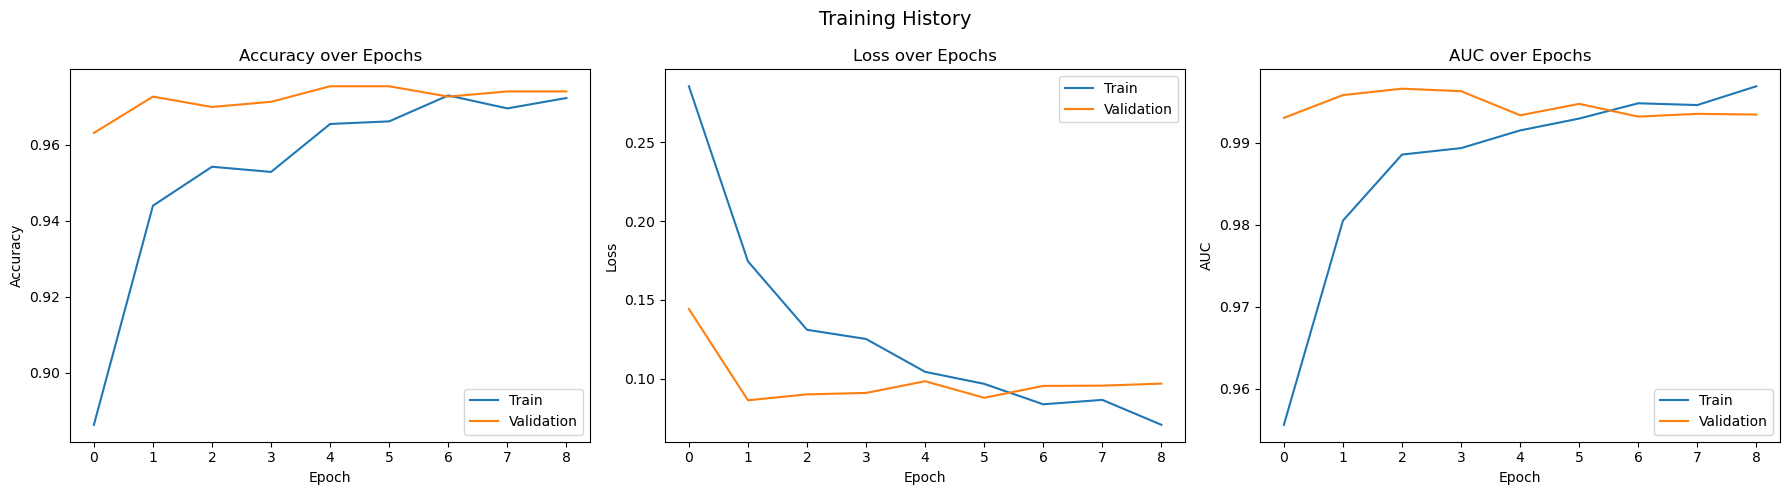

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

axes[2].plot(history.history['auc'], label='Train')
axes[2].plot(history.history['val_auc'], label='Validation')
axes[2].set_title('AUC over Epochs')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()

plt.suptitle('Training History', fontsize=14)
plt.tight_layout()
plt.show()

## confusion matrix , classification report

Running predictions on validation set...
46/46 ━━━━━━━━━━━━━━━━━━━━ 19s 299ms/step

Classification Report:
              precision    recall  f1-score   support

       No DR       0.98      0.95      0.97       361
      Has DR       0.96      0.98      0.97       372

    accuracy                           0.97       733
   macro avg       0.97      0.97      0.97       733
weighted avg       0.97      0.97      0.97       733



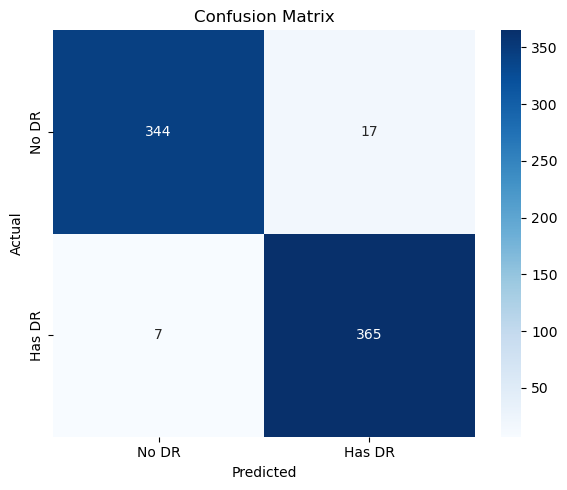

In [32]:
# Evaluate on validation set properly
val_images = []
val_labels = []

for _, row in val_data.iterrows():
    img = load_and_preprocess(row['image_path'])
    val_images.append(img)
    val_labels.append(row['binary_label'])

val_images = np.array(val_images)
val_labels = np.array(val_labels)

print("Running predictions on validation set...")
y_pred_probs = model.predict(val_images, batch_size=16)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = val_labels

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['No DR', 'Has DR']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No DR', 'Has DR'],
            yticklabels=['No DR', 'Has DR'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## sample predictions visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


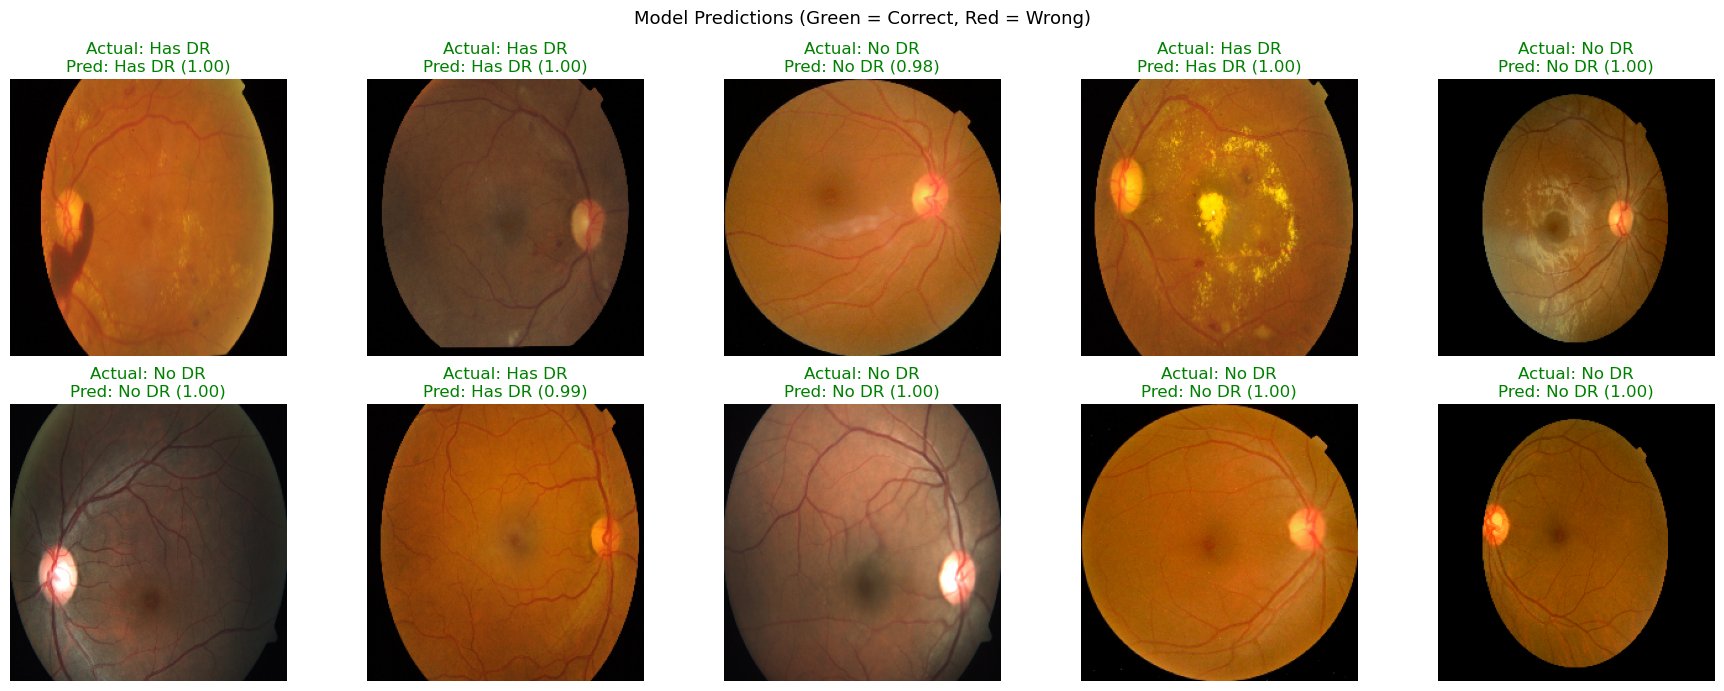

In [30]:
sample_df = val_data.sample(10, random_state=7).reset_index(drop=True)

images = np.array([load_and_preprocess(row['image_path']) for _, row in sample_df.iterrows()])
preds = model.predict(images)
pred_labels = (preds > 0.5).astype(int).flatten()

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, (_, row) in enumerate(sample_df.iterrows()):
    img = cv2.imread(row['image_path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    axes[i].imshow(img)
    actual = "No DR" if row['binary_label'] == 0 else "Has DR"
    predicted = "No DR" if pred_labels[i] == 0 else "Has DR"
    confidence = preds[i][0] if pred_labels[i] == 1 else 1 - preds[i][0]
    color = "green" if row['binary_label'] == pred_labels[i] else "red"
    axes[i].set_title(f"Actual: {actual}\nPred: {predicted} ({confidence:.2f})", color=color)
    axes[i].axis('off')

plt.suptitle("Model Predictions (Green = Correct, Red = Wrong)", fontsize=13)
plt.tight_layout()
plt.show()

## ROC Curve

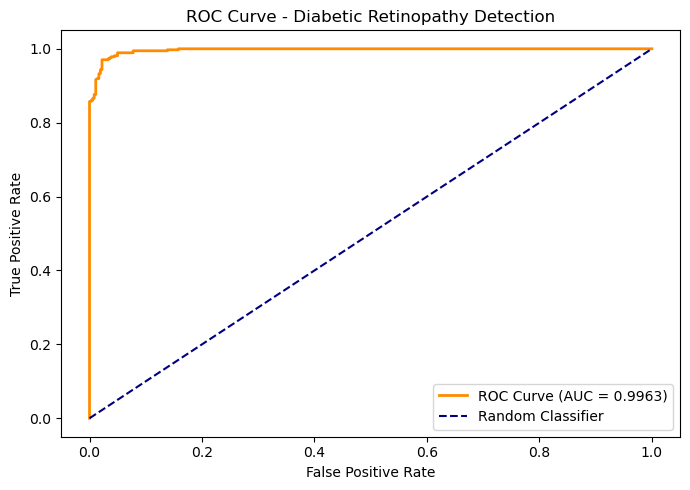

In [33]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Diabetic Retinopathy Detection')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## model save

In [11]:
model_save_path = os.path.join(base_path, "retinopathy_model.h5")
model.save(model_save_path)
print(f"Model saved to: {model_save_path}")

Model saved to: D:/AI COURSE/Daily_practice/PROJECTS/Retinopathy/aptos2019-blindness-detection/retinopathy_model.h5
